In [199]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from wordcloud import WordCloud

In [200]:
df_analysis = pd.read_csv("oscars_movies_merged.csv")

df_analysis["genre_list"] = df_analysis["genre_list"].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else []
)

In [201]:
len(df_analysis)

3034

In [202]:
df_analysis["oscar_nominated"].mean()

np.float64(0.17600527356624918)

In [203]:
# create genre-level dataset (movies appear in every listed genre)
df_genres = df_analysis.explode("genre_list").copy()
df_genres = df_genres.rename(columns={"genre_list": "genre"})

In [204]:
# compute nomination statistics by genre
genre_stats = (
    df_genres.groupby("genre")
    .agg(
        nomination_rate=("oscar_nominated","mean"),
        n_movies=("oscar_nominated","count")
    )
)
# keep only genres with at least 100 films
genre_stats = genre_stats[genre_stats["n_movies"] >= 100]

# sort genres by nomination rate
genre_stats = genre_stats.sort_values("nomination_rate", ascending=False)

genre_stats

,nomination_rate,n_movies
genre,,
History,0.366412,131
Animation,0.338776,245
Family,0.265753,365
Adventure,0.256024,664
Drama,0.251227,1222
Fantasy,0.238095,378
Romance,0.211982,434
Science Fiction,0.191781,438
Action,0.150985,914


Genres represented by fewer than 100 films were excluded from the analysis in order to ensure that the estimated nomination rates are based on sufficiently large samples.

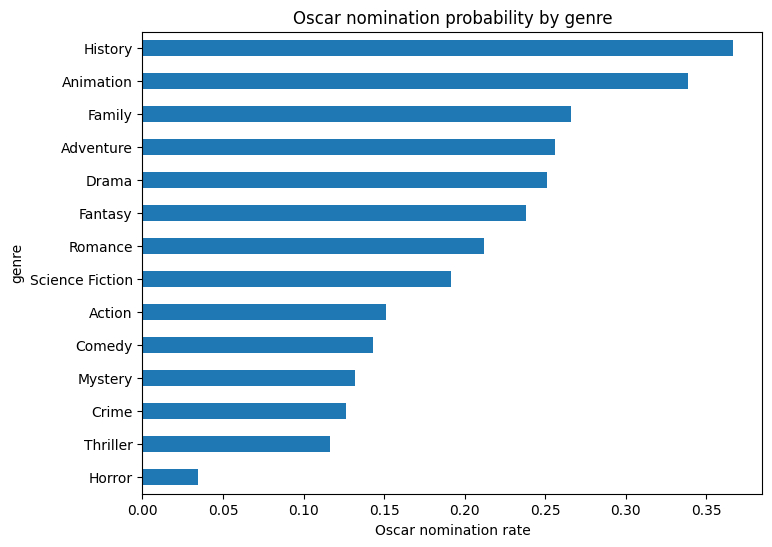

In [205]:
plt.figure(figsize=(8,6))

genre_stats["nomination_rate"].sort_values().plot(kind="barh")

plt.xlabel("Oscar nomination rate")
plt.title("Oscar nomination probability by genre")

plt.show()

Genres such as history, animation, and family show the highest nomination probabilities, while genres like horror, thriller, and crime exhibit substantially lower nomination rates.

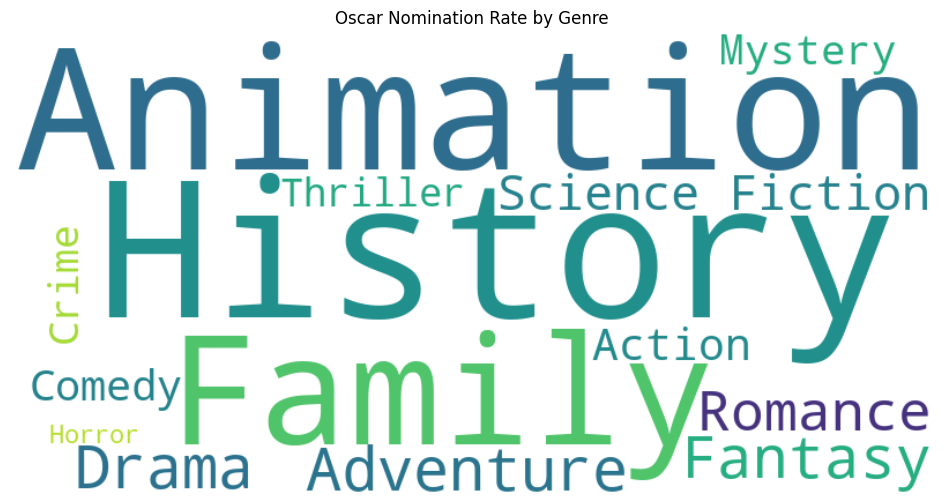

In [206]:
genre_dict = genre_stats["nomination_rate"].to_dict()

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="viridis"
).generate_from_frequencies(genre_dict)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Oscar Nomination Rate by Genre")

plt.show()

The analysis shows substantial differences in Oscar nomination rates across film genres. In the filtered sample, history films have the highest nomination rate, with about 36.6% of films receiving at least one Oscar nomination. Animation also shows a comparatively high nomination rate of around 33.9%, followed by family, adventure, and drama films, all of which have nomination rates between roughly 25% and 27%.

Genres such as fantasy, romance, and science fiction occupy a middle range, with nomination probabilities of about 19% to 24%. In contrast, action, comedy, mystery, crime, and thriller films show noticeably lower nomination rates, generally between about 11% and 15%. Horror films have by far the lowest nomination rate in the sample, at only about 3.4%.

Overall, the results suggest that genre is strongly associated with the likelihood of receiving an Academy Award nomination. It should also be noted that some genres, such as animation, benefit from category-specific Academy Award structures, which may partly explain their relatively high nomination rates.

In [207]:
genre_multi_nom_rate = (
    df_genres.assign(multi_nom = df_genres["oscar_nominations"] >= 2)
    .groupby("genre")
    .agg(
        multi_nom_rate=("multi_nom","mean"),
        n_movies=("multi_nom","count")
    )
)

genre_multi_nom_rate = genre_multi_nom_rate[genre_multi_nom_rate["n_movies"] >= 100]

genre_multi_nom_rate.sort_values("multi_nom_rate", ascending=False)

,multi_nom_rate,n_movies
genre,,
History,0.290076,131
Drama,0.166939,1222
Romance,0.152074,434
Adventure,0.123494,664
Animation,0.118367,245
Fantasy,0.116402,378
Family,0.098630,365
Science Fiction,0.095890,438
Crime,0.081933,476


To further investigate the potential animation category effect, we examined the frequency with which films receive multiple Oscar nominations (two or more). This analysis helps determine whether the relatively high nomination rate observed for animated films reflects broader recognition across categories or is primarily driven by a single dedicated category.

The results show that history films have the highest proportion of multiple nominations, with approximately 29.0% of films receiving at least two Oscar nominations. Drama and romance films also show comparatively high rates of multiple nominations, with about 16.7% and 15.2% respectively. Adventure, animation, and fantasy films follow with nomination rates between roughly 11% and 12%.

Notably, animated films, which previously showed one of the highest overall nomination rates, have a lower rate of receiving multiple nominations compared to genres such as history, drama, and romance. This suggests that while animated films are relatively likely to receive at least one nomination, they are less frequently nominated across multiple Oscar categories.

Genres such as action, thriller, mystery, and comedy show comparatively low rates of multiple nominations, generally below 8%. Horror films again display the lowest values, with only about 2% of films receiving two or more nominations.

Overall, these results support the interpretation that the relatively high nomination rate observed for animated films may partly reflect the presence of a dedicated award category rather than broader recognition across multiple Oscar categories.

In [208]:
df_analysis["log_budget"] = np.log(df_analysis["budget"])

In [209]:
df_analysis["budget_group"] = pd.qcut(df_analysis["budget"],5)

In [210]:
df_analysis.groupby("budget_group")["oscar_nominated"].mean()

budget_group
(0.999, 3000000.0]           0.012559
(3000000.0, 13000000.0]      0.104811
(13000000.0, 30000000.0]     0.174475
(30000000.0, 70000000.0]     0.228333
(70000000.0, 489900000.0]    0.369128
Name: oscar_nominated, dtype: float64

In [211]:
genre_counts = df_analysis["main_genre"].value_counts()

KeyError: 'main_genre'

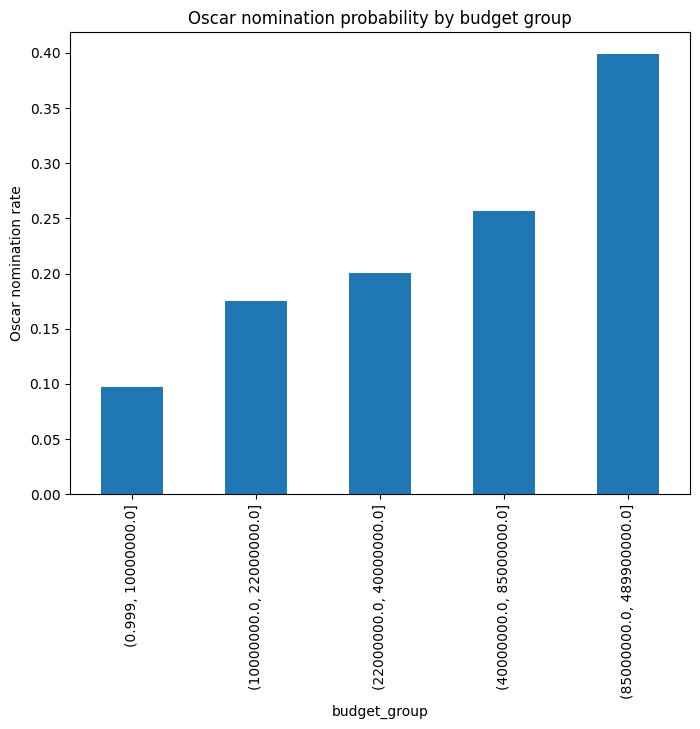

In [ ]:
import matplotlib.pyplot as plt

budget_rates = df_analysis.groupby("budget_group")["oscar_nominated"].mean()

plt.figure(figsize=(8,6))
budget_rates.plot(kind="bar")

plt.ylabel("Oscar nomination rate")
plt.title("Oscar nomination probability by budget group")

plt.show()

The analysis also reveals a clear relationship between production budget and Oscar nomination rates. Films with smaller budgets (below $10 million) have a nomination rate of about 10%. As budgets increase, the likelihood of receiving an Oscar nomination also rises steadily.

Films with budgets between $40 million and $85 million show a nomination rate of around 26%, while the highest-budget films (above $85 million) have the highest nomination rate at approximately 40%.

Overall, the results suggest that higher-budget productions are considerably more likely to receive Oscar nominations than lower-budget films.

In [ ]:
genre_counts = df_analysis["main_genre"].value_counts()

valid_genres = genre_counts[genre_counts >= 30].index

df_filtered = df_analysis[df_analysis["main_genre"].isin(valid_genres)]

In [ ]:
df_filtered["budget_group"] = pd.qcut(df_filtered["budget"], 5)

In [ ]:
genre_budget = (
    df_filtered
    .groupby(["main_genre", "budget_group"])["oscar_nominated"]
    .mean()
)

genre_budget

main_genre       budget_group             
Action           (0.999, 10000000.0]          0.018868
                 (10000000.0, 22000000.0]     0.016949
                 (22000000.0, 40000000.0]     0.097826
                 (40000000.0, 85000000.0]     0.171171
                 (85000000.0, 489900000.0]    0.297297
Adventure        (0.999, 10000000.0]          0.000000
                 (10000000.0, 22000000.0]     0.312500
                 (22000000.0, 40000000.0]     0.074074
                 (40000000.0, 85000000.0]     0.290323
                 (85000000.0, 489900000.0]    0.380435
Animation        (0.999, 10000000.0]          0.050000
                 (10000000.0, 22000000.0]     0.000000
                 (22000000.0, 40000000.0]     0.181818
                 (40000000.0, 85000000.0]     0.400000
                 (85000000.0, 489900000.0]    0.625000
Comedy           (0.999, 10000000.0]          0.105769
                 (10000000.0, 22000000.0]     0.110000
                 (2200

In [ ]:
genre_budget_table = (
    df_filtered
    .groupby(["main_genre","budget_group"])["oscar_nominated"]
    .mean()
    .unstack()
)

genre_budget_table

budget_group,"(0.999, 10000000.0]","(10000000.0, 22000000.0]","(22000000.0, 40000000.0]","(40000000.0, 85000000.0]","(85000000.0, 489900000.0]"
main_genre,,,,,
Action,0.018868,0.016949,0.097826,0.171171,0.297297
Adventure,0.000000,0.312500,0.074074,0.290323,0.380435
Animation,0.050000,0.000000,0.181818,0.400000,0.625000
Comedy,0.105769,0.110000,0.130435,0.168831,0.214286
Crime,0.066667,0.083333,0.227273,0.200000,0.428571
Drama,0.189189,0.400000,0.489796,0.500000,0.733333
Family,0.142857,0.000000,0.153846,0.190476,0.608696
Fantasy,0.000000,0.285714,0.090909,0.176471,0.269231
Horror,0.000000,0.047619,0.033333,0.157895,0.333333


When considering both genre and budget simultaneously, the results show that higher production budgets generally increase the likelihood of receiving an Oscar nomination across most genres. This effect is particularly pronounced for dramatic films, where nomination rates rise from about 19% for low-budget productions to more than 70% for the highest-budget films.

A similar pattern can be observed for genres such as adventure and animation, where larger budgets are associated with substantially higher nomination probabilities. In contrast, genres like comedy and horror maintain relatively low nomination rates even at higher budget levels.

Overall, the results indicate that both genre and production budget play an important role in determining the likelihood of receiving an Oscar nomination.

In [ ]:
genre_budget_stats = genre_budget_stats.reset_index()

In [ ]:
genre_budget_stats = (
    df_filtered
    .groupby(["main_genre","budget_group"])
    .agg(
        nomination_rate=("oscar_nominated","mean"),
        n_movies=("oscar_nominated","count")
    )
    .reset_index()
)
genre_budget_stats = genre_budget_stats[
    genre_budget_stats["n_movies"] >= 5
]

In [ ]:
genre_budget_matrix = genre_budget_stats.pivot(
    index="main_genre",
    columns="budget_group",
    values="nomination_rate"
)

genre_budget_matrix

budget_group,"(0.999, 10000000.0]","(10000000.0, 22000000.0]","(22000000.0, 40000000.0]","(40000000.0, 85000000.0]","(85000000.0, 489900000.0]"
main_genre,,,,,
Action,0.018868,0.016949,0.097826,0.171171,0.297297
Adventure,0.000000,0.312500,0.074074,0.290323,0.380435
Animation,0.050000,0.000000,0.181818,0.400000,0.625000
Comedy,0.105769,0.110000,0.130435,0.168831,0.214286
Crime,0.066667,0.083333,0.227273,0.200000,0.428571
Drama,0.189189,0.400000,0.489796,0.500000,0.733333
Family,0.142857,0.000000,0.153846,0.190476,0.608696
Fantasy,0.000000,0.285714,0.090909,0.176471,0.269231
Horror,0.000000,0.047619,0.033333,0.157895,NaN


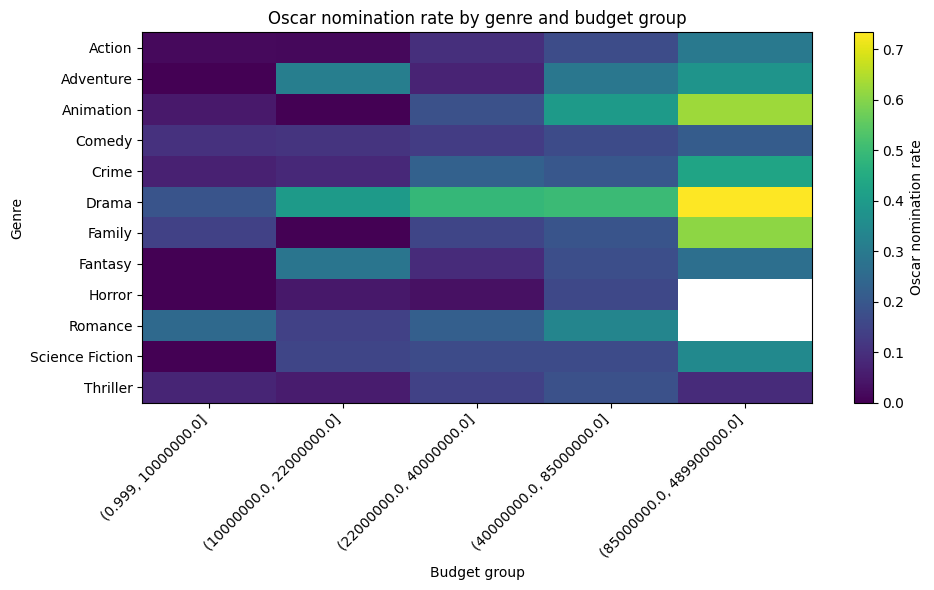

In [ ]:
plt.figure(figsize=(10, 6))
plt.imshow(genre_budget_matrix, aspect="auto")
plt.colorbar(label="Oscar nomination rate")

plt.xticks(
    range(len(genre_budget_matrix.columns)),
    genre_budget_matrix.columns,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(genre_budget_matrix.index)),
    genre_budget_matrix.index
)

plt.title("Oscar nomination rate by genre and budget group")
plt.xlabel("Budget group")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()